In [ ]:
!pip install tensorflow
!pip install SpeechRecognition
!pip install gTTS

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
train_df = pd.read_csv("sign_mnist_train.csv", usecols=range(785))
test_df = pd.read_csv("sign_mnist_test.csv", usecols=range(785))

In [ ]:
# Preprocess data
y_train = train_df['label'].values
y_test = test_df['label'].values
X_train = train_df.drop('label', axis=1).values
X_test = test_df.drop('label', axis=1).values

X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

num_classes = 26
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)


In [ ]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_train)

In [ ]:
from tensorflow.keras import Input

# Build the model
model = tf.keras.Sequential([
    Input(shape=(28, 28, 1)),  # Explicitly define the input shape
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])


In [ ]:
# Learning Rate Scheduling
def lr_schedule(epoch):
    lr = 1e-3
    if epoch > 15:
        lr *= 0.5e-3
    elif epoch > 10:
        lr *= 1e-3
    elif epoch > 5:
        lr *= 1e-2
    return lr

lr_scheduler = LearningRateScheduler(lr_schedule)


In [ ]:
# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [ ]:
# Model Checkpointing
checkpoint = ModelCheckpoint("best_model.keras", monitor='val_accuracy', save_best_only=True, mode='max')

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    epochs=30,
                    validation_data=(X_test, y_test),
                    callbacks=[lr_scheduler, early_stopping, checkpoint])


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


858/858 ━━━━━━━━━━━━━━━━━━━━ 57s 65ms/step - accuracy: 0.1768 - loss: 2.7474 - val_accuracy: 0.7483 - val_loss: 0.7941 - learning_rate: 0.0010
Epoch 2/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.5893 - loss: 1.2352 - val_accuracy: 0.8476 - val_loss: 0.4654 - learning_rate: 0.0010
Epoch 3/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.6916 - loss: 0.8994 - val_accuracy: 0.9241 - val_loss: 0.2887 - learning_rate: 0.0010
Epoch 4/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.7491 - loss: 0.7162 - val_accuracy: 0.9437 - val_loss: 0.2066 - learning_rate: 0.0010
Epoch 5/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - accuracy: 0.8006 - loss: 0.5892 - val_accuracy: 0.9572 - val_loss: 0.1561 - learning_rate: 0.0010
Epoch 6/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.8153 - loss: 0.5281 - val_accuracy: 0.9642 - val_loss: 0.1145 - learning_rate: 0.0010
Epoch 7/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.8385 - loss: 0.4638

In [ ]:
# Define states and actions for Q-learning
states = ['Beginner', 'Intermediate', 'Advanced']
actions = ['Next Easy Exercise', 'Next Moderate Exercise', 'Next Hard Exercise']


In [ ]:
# Initialize Q-table
q_table = np.zeros((len(states), len(actions)))

In [ ]:
# Reward function for user performance
def get_reward(correct, response_time):
    if correct:
        if response_time < 2.0:
            return 10  # High reward for quick correct answer
        else:
            return 5  # Moderate reward for slower correct answer
    else:
        return -5  # Negative reward for incorrect answer


In [ ]:
# Q-learning update function
def update_q_table(state_index, action_index, reward, next_state_index, alpha=0.1, gamma=0.9):
    best_next_action = np.max(q_table[next_state_index])
    q_table[state_index, action_index] = (1 - alpha) * q_table[state_index, action_index] + \
                                         alpha * (reward + gamma * best_next_action)


In [ ]:
#state-action management function
def choose_action(state_index, epsilon=0.1):
    if np.random.rand() < epsilon:
        return np.random.choice(len(actions))  # Exploration
    else:
        return np.argmax(q_table[state_index])  # Exploitation

In [ ]:
#Q-learning integration during evaluation
def evaluate_model():
    state = 0  # Starting at 'Beginner'
    action_history = []
    reward_history = []

    for i in range(5):  # Simulate 5 evaluation steps
        action = choose_action(state)
        print(f"State: {states[state]}, Action Taken: {actions[action]}")


In [ ]:
# More iterations for better learning
iterations = 200

# Improved reward scaling
def get_reward(correct, response_time):
    if correct:
        if response_time < 2.0:
            return 100  # High reward for quick correct answer
        else:
            return 50  # Moderate reward for slower correct answer
    else:
        return -50  # Negative reward for incorrect answer

state = 0
reward_history = []
action_history = []

for i in range(iterations):
    action = choose_action(state)
    correct = np.random.choice([True, False])
    response_time = np.random.uniform(1.0, 3.0)

    reward = get_reward(correct, response_time)
    reward_history.append(reward)
    action_history.append(actions[action])

    next_state = min(state + 1, len(states) - 1) if correct else state
    update_q_table(state, action, reward, next_state)
    state = next_state

print("Final Q-table after more iterations:")
print(q_table)




Final Q-table after more iterations:
[[ -5.          10.           0.        ]
 [ 10.           0.           0.        ]
 [ 17.65075744 106.79435061  46.44294789]]


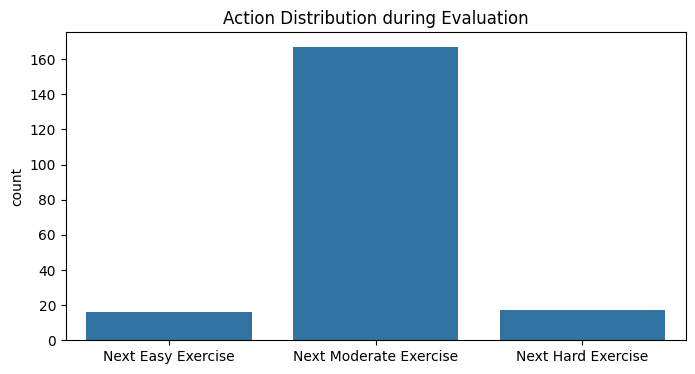

In [ ]:
# Bar chart of actions taken
plt.figure(figsize=(8, 4))
sns.countplot(x=action_history)
plt.title('Action Distribution during Evaluation')
plt.show()

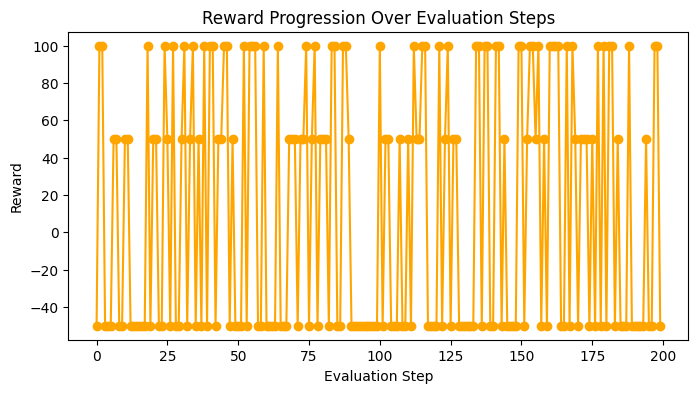

In [ ]:
# Line chart of rewards over time
plt.figure(figsize=(8, 4))
plt.plot(reward_history, marker='o', color='orange')
plt.title('Reward Progression Over Evaluation Steps')
plt.xlabel('Evaluation Step')
plt.ylabel('Reward')
plt.show()

In [ ]:
def evaluate_model():
    state = 0  # Starting at 'Beginner'
    action_history = []
    reward_history = []

    for i in range(200):  # Increased iterations for better learning
        action = choose_action(state)
        print(f"State: {states[state]}, Action Taken: {actions[action]}")

        # Simulate user feedback
        correct = np.random.choice([True, False])
        response_time = np.random.uniform(1.0, 3.0)  # Random response time between 1 to 3 seconds

        reward = get_reward(correct, response_time)
        reward_history.append(reward)
        action_history.append(actions[action])

        next_state = min(state + 1, len(states) - 1) if correct else state

        update_q_table(state, action, reward, next_state)
        state = next_state

    print("Final Q-table:")
    print(q_table)

    # Properly return action and reward histories
    return action_history, reward_history


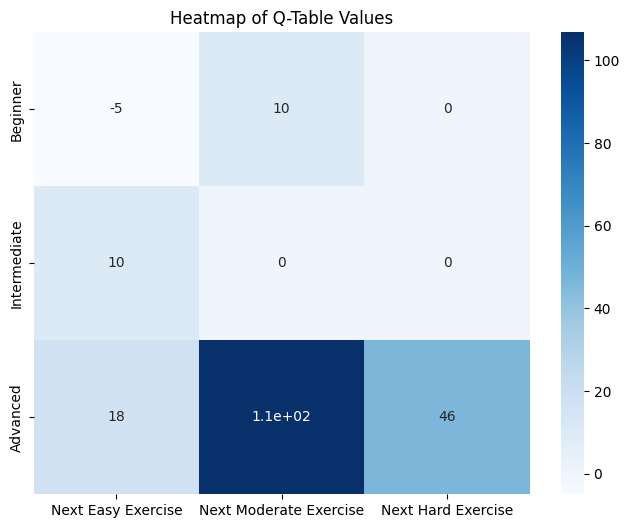

In [ ]:
# Heatmap of Q-table values
plt.figure(figsize=(8, 6))
sns.heatmap(q_table, annot=True, cmap='Blues', xticklabels=actions, yticklabels=states)
plt.title('Heatmap of Q-Table Values')
plt.show()

State: Beginner, Action Taken: Next Moderate Exercise
State: Intermediate, Action Taken: Next Easy Exercise
State: Intermediate, Action Taken: Next Easy Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Taken: Next Moderate Exercise
State: Advanced, Action Take

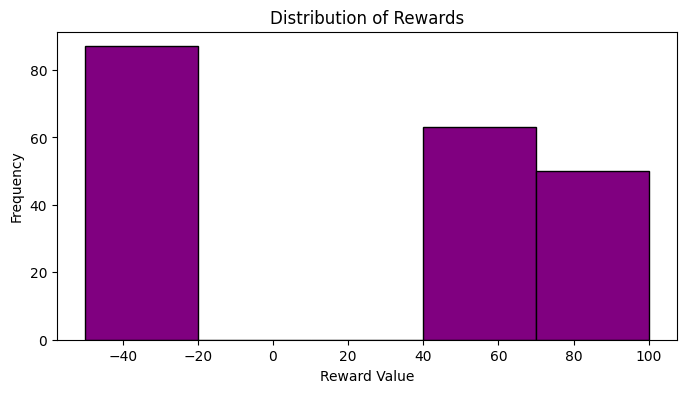

In [ ]:
# Evaluate the model and get the action and reward history
actions_taken, rewards_received = evaluate_model()

# Plot the histogram of rewards
plt.figure(figsize=(8, 4))
plt.hist(rewards_received, bins=5, color='purple', edgecolor='black')
plt.title('Distribution of Rewards')
plt.xlabel('Reward Value')
plt.ylabel('Frequency')
plt.show()

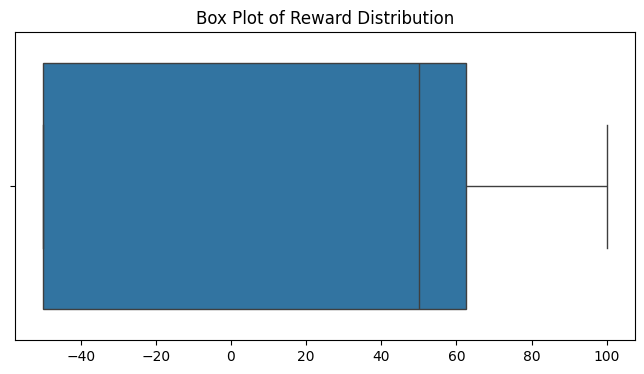

In [ ]:
# Box plot for reward distribution
plt.figure(figsize=(8, 4))
sns.boxplot(x=rewards_received)
plt.title('Box Plot of Reward Distribution')
plt.show()

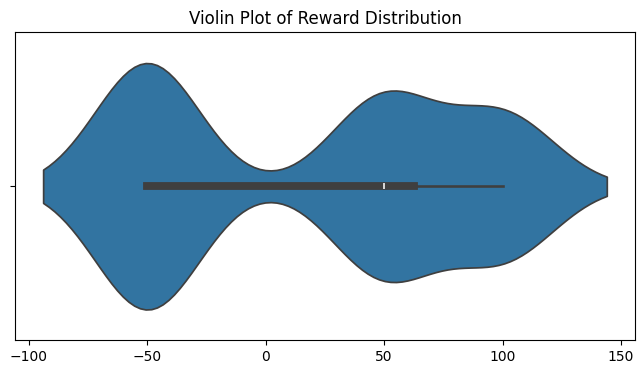

In [ ]:
# Violin plot for reward distribution
plt.figure(figsize=(8, 4))
sns.violinplot(x=rewards_received)
plt.title('Violin Plot of Reward Distribution')
plt.show()


In [ ]:
# Save the model
model.save("sign_language_model.keras")

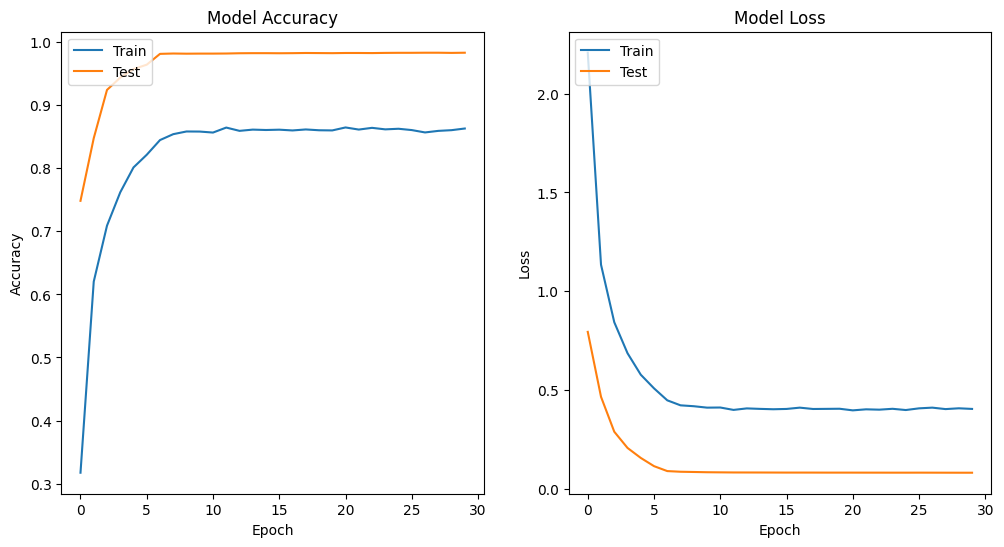

In [ ]:
# Plotting the results
def plot_history(history):
    plt.figure(figsize=(12, 6))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')

    plt.show()

# Call the function to plot the history
plot_history(history)

In [ ]:
# Speech Recognition Function
import speech_recognition as sr

def speech_to_text():
    recognizer = sr.Recognizer()
    with sr.Microphone() as source:
        print("Listening for speech...")
        try:
            audio = recognizer.listen(source)
            text = recognizer.recognize_google(audio)
            print("Recognized Text:", text)
            return text
        except sr.UnknownValueError:
            print("Could not understand audio")
        except sr.RequestError:
            print("Speech Recognition service unavailable")


In [ ]:
# Text-to-Speech Function
from gtts import gTTS

def text_to_speech(text):
    tts = gTTS(text=text, lang='en')
    tts.save("output.mp3")
    print("Speech synthesized and saved as output.mp3")


In [ ]:
# Reinforcement Learning (Q-Learning Skeleton)
import random

class ReinforcementLearningAgent:
    def __init__(self):
        self.q_table = {}

    def choose_action(self, state):
        return random.choice(['Easy', 'Medium', 'Hard'])

    def update_q_value(self, state, action, reward):
        self.q_table[(state, action)] = reward

agent = ReinforcementLearningAgent()
current_state = "start"
selected_action = agent.choose_action(current_state)
print(f"Selected Action: {selected_action}")


Selected Action: Medium


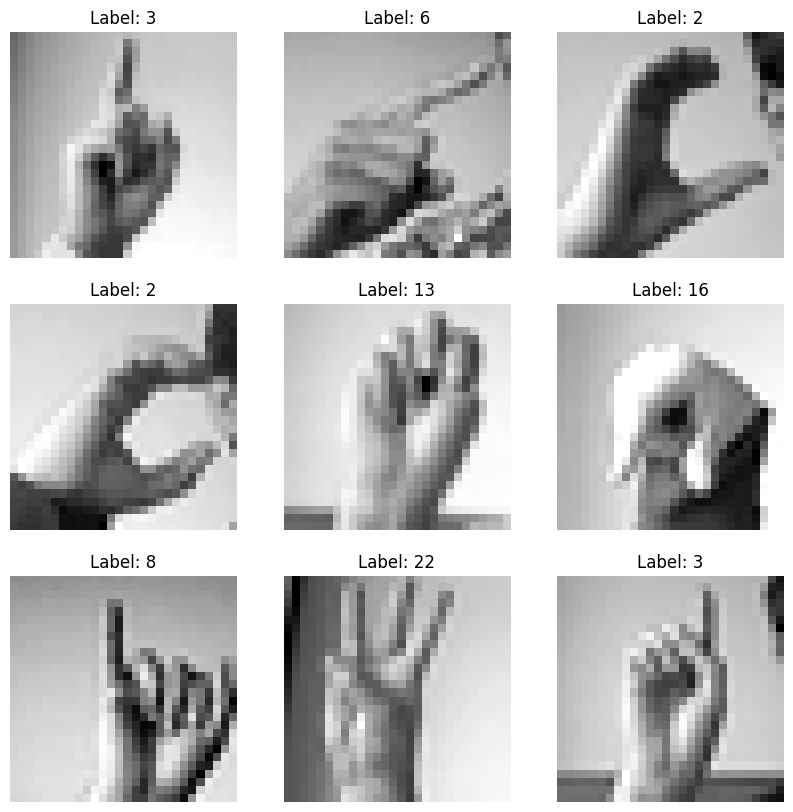

In [ ]:
# Additional Visualizations
def plot_sample_images(X, y, num_samples=9):
    plt.figure(figsize=(10, 10))
    for i in range(num_samples):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X[i].reshape(28, 28), cmap='gray')
        plt.title(f"Label: {np.argmax(y[i])}")
        plt.axis('off')
    plt.show()

plot_sample_images(X_train, y_train)

In [ ]:
# Webcam-based Gesture Recognition
import cv2
def webcam_recognition(model):
    cap = cv2.VideoCapture(0)
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Preprocess the frame for model input
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        resized_frame = cv2.resize(gray_frame, (28, 28))
        input_frame = resized_frame.reshape(1, 28, 28, 1) / 255.0
        prediction = np.argmax(model.predict(input_frame), axis=-1)
        cv2.putText(frame, f"Predicted: {chr(prediction[0] + 65)}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.imshow('Sign Language Recognition', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


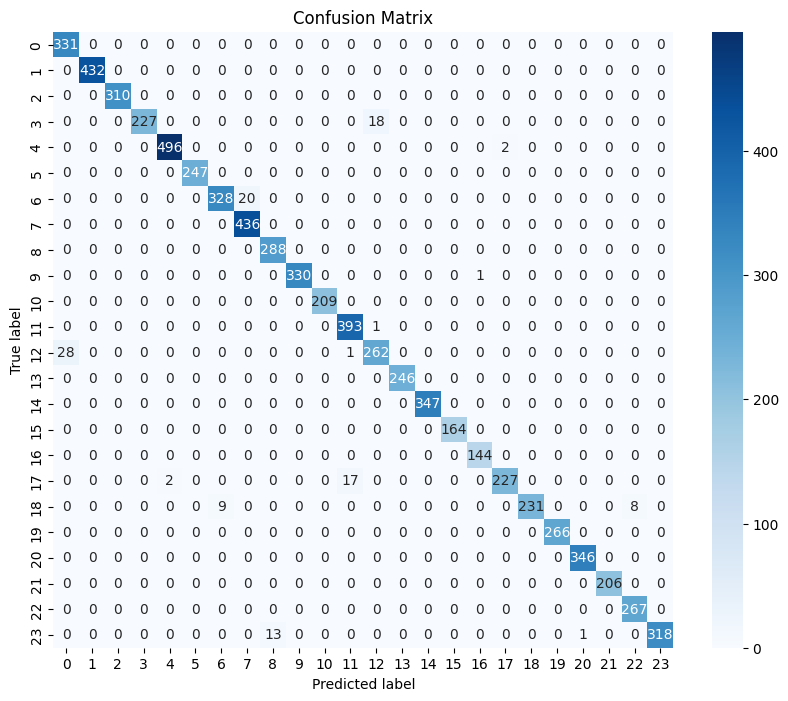

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       331
           1       1.00      1.00      1.00       432
           2       1.00      1.00      1.00       310
           3       1.00      0.93      0.96       245
           4       1.00      1.00      1.00       498
           5       1.00      1.00      1.00       247
           6       0.97      0.94      0.96       348
           7       0.96      1.00      0.98       436
           8       0.96      1.00      0.98       288
          10       1.00      1.00      1.00       331
          11       1.00      1.00      1.00       209
          12       0.96      1.00      0.98       394
          13       0.93      0.90      0.92       291
          14       1.00      1.00      1.00       246
          15       1.00      1.00      1.00       347
          16       1.00      1.00      1.00       164
          17       0.99      1.00      1.00       144
          18       0.99    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


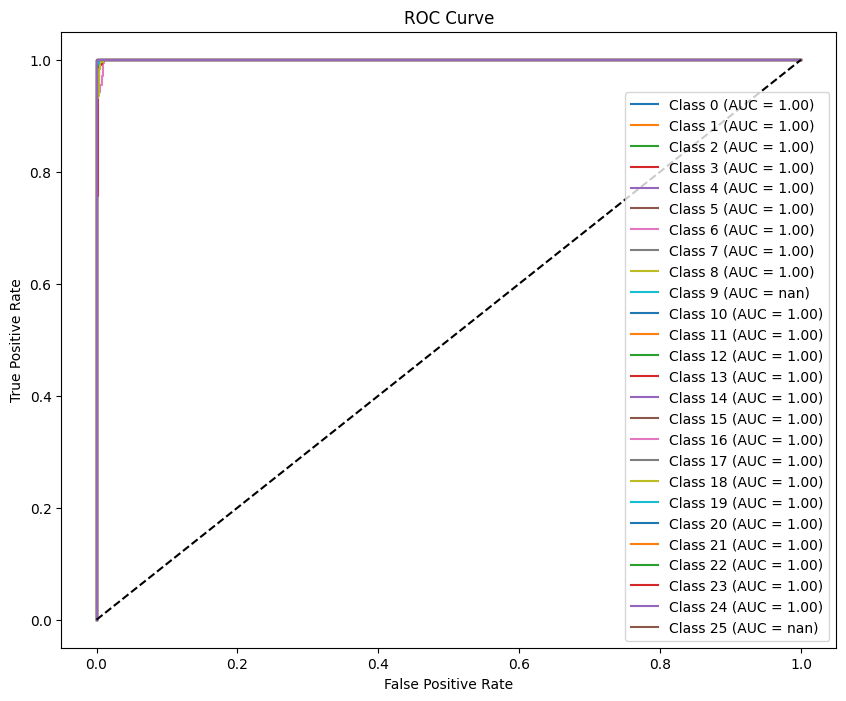

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_true, classes=np.arange(num_classes))
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# END
